# 🧠 Tripolar EEG — Group Analysis (All Subjects)

This notebook loads **all subjects**, runs the per-subject analysis, and produces **group-level statistical comparisons** of tEEG vs conventional electrodes.

**Prerequisites:** `eeg_analysis.py` and all subject data files in `data/`.

---

### Research Question
Are tripolar tEEG electrodes as effective as conventional disc electrodes for detecting:
1. **Visually-induced alpha waves** (checkerboard VEP paradigm)
2. **Spontaneous alpha** (eyes-open vs eyes-closed, Berger effect)


In [1]:
import sys
sys.path.insert(0, '.')
from tripolar_eeg.eeg_analysis import *
from scipy import stats

from pathlib import Path
import re

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

# -----------------------------------------------------------------------------
# Auto-save all displayed figures into output/<section>/
# -----------------------------------------------------------------------------

_cwd = Path.cwd().resolve()
_fallback_root = Path('/home/tnlab_sk/Desktop/Tripolar_EEG')
if (_cwd / 'data').exists():
    repo_root = _cwd
elif (_cwd.parent / 'data').exists():
    repo_root = _cwd.parent
elif (_fallback_root / 'data').exists():
    repo_root = _fallback_root
else:
    repo_root = _cwd

OUTPUT_BASE_DIR = (repo_root / 'output')
OUTPUT_BASE_DIR.mkdir(parents=True, exist_ok=True)

_current_section = 'misc'
_fig_counters = {}
_original_show = plt.show


def _slug(part: str) -> str:
    part = str(part).strip().lower()
    part = re.sub(r'[^a-z0-9._\- ]+', '', part)
    part = re.sub(r'\s+', '_', part)
    return part or 'unnamed'


def set_output_section(section: str):
    """Route subsequent plt.show() saves to output/<section>/.

    Supports nested sections like 'per_subject_summary/SK1'.
    """
    global _current_section
    section = str(section).strip().strip('/')
    if not section:
        section = 'misc'

    parts = [_slug(p) for p in section.split('/') if p.strip()]
    _current_section = '/'.join(parts) if parts else 'misc'

    out_dir = OUTPUT_BASE_DIR.joinpath(*_current_section.split('/'))
    out_dir.mkdir(parents=True, exist_ok=True)
    return out_dir


def _show_and_save(*args, **kwargs):
    fig = plt.gcf()
    out_dir = set_output_section(_current_section)
    idx = _fig_counters.get(_current_section, 0) + 1
    _fig_counters[_current_section] = idx

    fname = out_dir / f'fig_{idx:03d}.png'
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    return _original_show(*args, **kwargs)


plt.show = _show_and_save

print(f"Ready ✓ (autosave → {OUTPUT_BASE_DIR})")

Ready ✓ (autosave → /home/tnlab_sk/Desktop/Tripolar_EEG/output)


## 1. Discover & Load All Subjects

In [2]:
from pathlib import Path

# Try to locate repo root so the notebook is portable across machines
cwd = Path.cwd().resolve()
if (cwd / 'data').exists():
    repo_root = cwd
elif (cwd.parent / 'data').exists():
    repo_root = cwd.parent
else:
    # Fall back to the path used in single_subject_analysis.ipynb
    repo_root = Path('/home/tnlab_sk/Desktop/Tripolar_EEG')

DATA_DIR = str((repo_root / 'data').resolve())

subjects_info = discover_subjects(DATA_DIR)
print(f"Found {len(subjects_info)} subjects:\n")
for s in subjects_info:
    avg_str = "✓ avg" if s['avg'] else "✗ avg"
    vmrk_str = "✓ mrk" if s['vmrk'] else "✗ mrk"
    print(f"  {s['name']:<15s}  {vmrk_str}  {avg_str}  ({s['basename']})")
print(f"\nUsing DATA_DIR = {DATA_DIR}")

Found 10 subjects:

  AH felt TCRE     ✓ mrk  ✓ avg  (AH felt TCRE 2-3-2026)
  CP1              ✓ mrk  ✓ avg  (CP1 2-22-26)
  Caitlin 1        ✓ mrk  ✓ avg  (Caitlin 1 2-11-26)
  Gab              ✓ mrk  ✓ avg  (Gab)
  Hunter1          ✓ mrk  ✓ avg  (Hunter1 217-26)
  LS1              ✓ mrk  ✓ avg  (LS1 2-11-26)
  LSF1             ✓ mrk  ✓ avg  (LSF1 2-11-26)
  LuciTest         ✓ mrk  ✓ avg  (LuciTest)
  SK1              ✓ mrk  ✓ avg  (SK1 2-19-2026)
  TU               ✓ mrk  ✓ avg  (TU 12-10-2026)

Using DATA_DIR = /home/tnlab_sk/Desktop/Tripolar_EEG/data


In [3]:
# Load and analyze all subjects
all_subjects = {}
all_results = {}
failed = []

for info in subjects_info:
    name = info['name']
    try:
        print(f"Loading {name}...", end=" ")
        subj = load_subject(DATA_DIR, subject_info=info)
        print(f"({subj['n_samples']/FS:.0f}s, {len(subj['stim_samples'])} stim, "
              f"{len(subj['events_oc'])} oc markers)", end=" ")
        
        res = analyze_subject(subj)
        all_subjects[name] = subj
        all_results[name] = res
        print("✓")
    except Exception as e:
        print(f"✗ FAILED: {e}")
        failed.append((name, str(e)))

print(f"\n{'═'*50}")
print(f"Successfully loaded: {len(all_results)} / {len(subjects_info)} subjects")
if failed:
    print(f"Failed: {[f[0] for f in failed]}")

Loading AH felt TCRE... (522s, 60 stim, 7 oc markers) ✓
Loading CP1... (543s, 40 stim, 11 oc markers) ✓
Loading Caitlin 1... (341s, 40 stim, 7 oc markers) ✓
Loading Gab... (527s, 30 stim, 8 oc markers) ✓
Loading Hunter1... (756s, 60 stim, 14 oc markers) ✓
Loading LS1... (359s, 40 stim, 7 oc markers) ✓
Loading LSF1... (395s, 40 stim, 9 oc markers) ✓
Loading LuciTest... (263s, 50 stim, 0 oc markers) ✓
Loading SK1... (450s, 60 stim, 7 oc markers) ✓
Loading TU... (382s, 40 stim, 7 oc markers) ✓

══════════════════════════════════════════════════
Successfully loaded: 10 / 10 subjects


## 2. Per-Subject Summary Dashboards

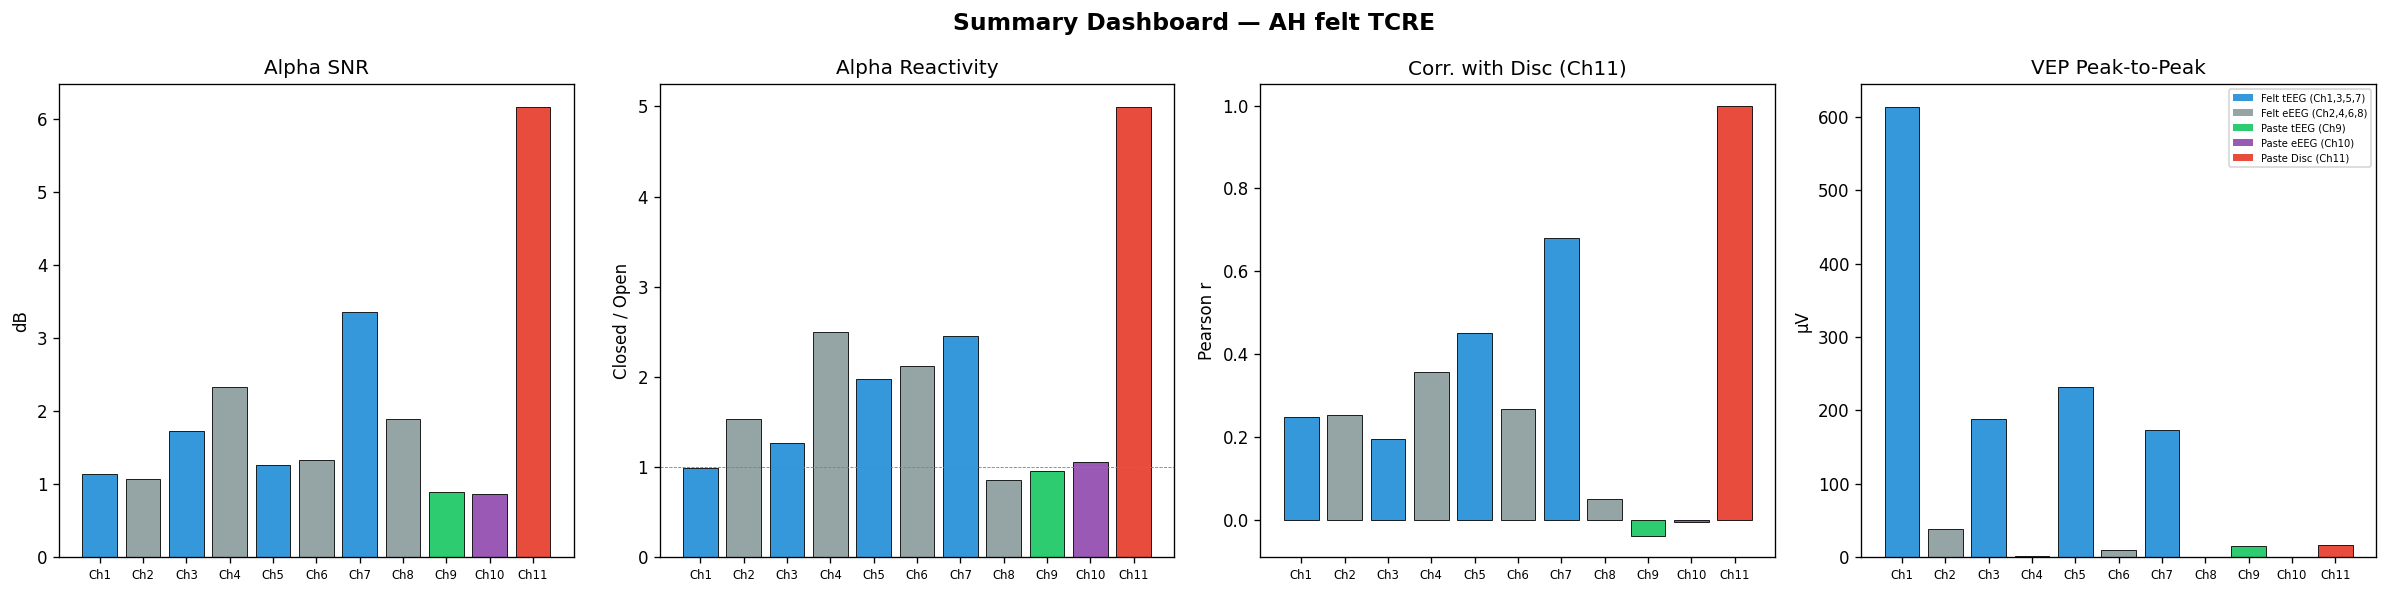

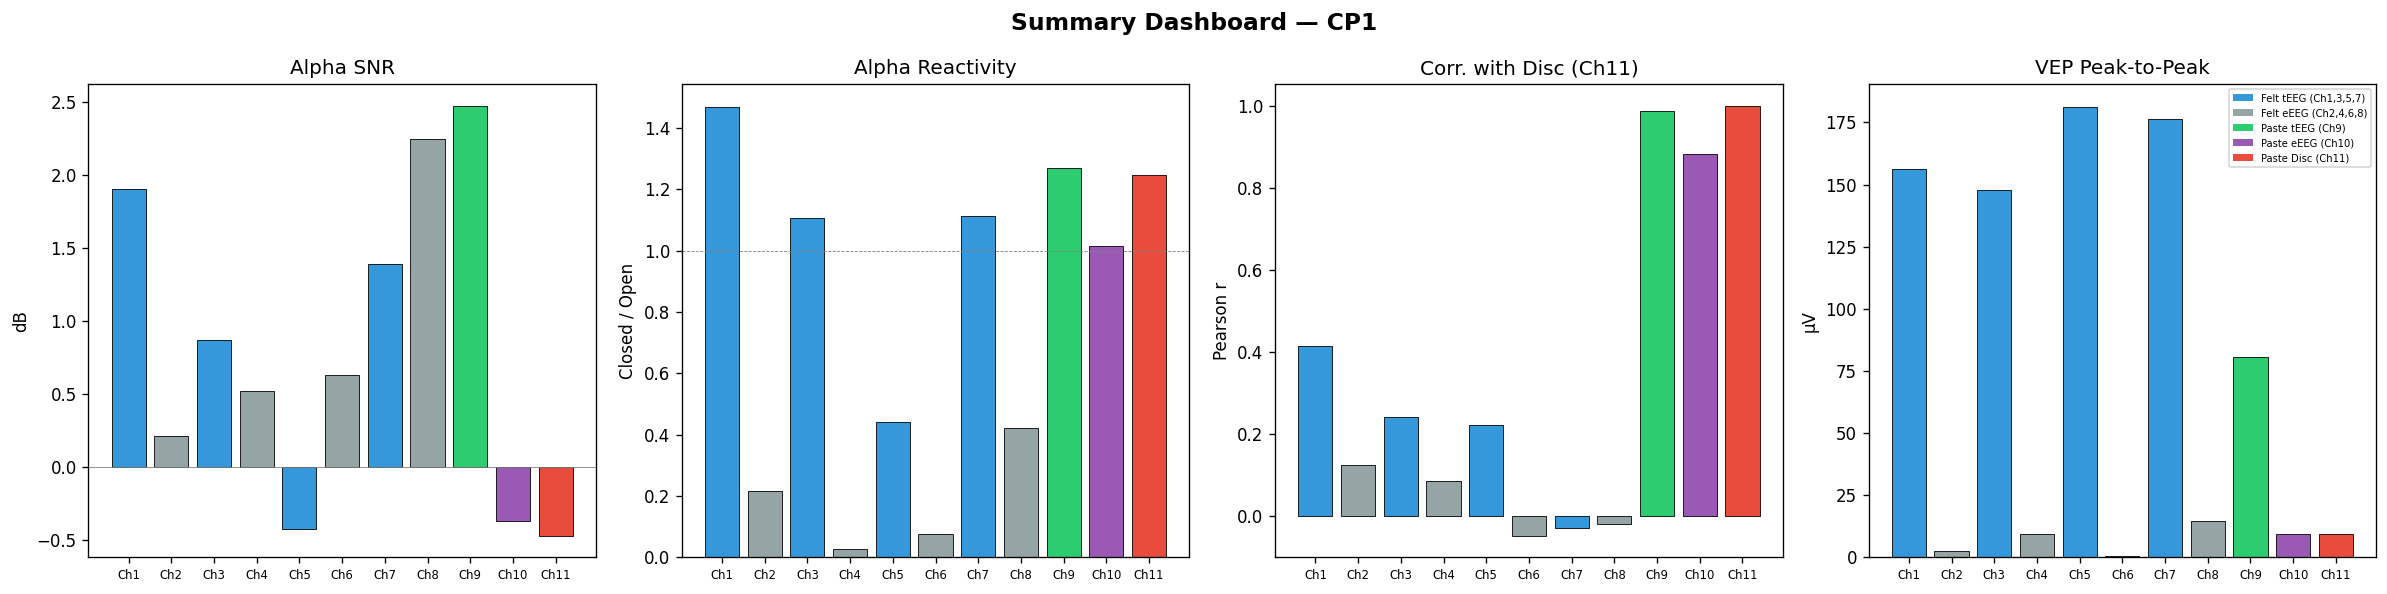

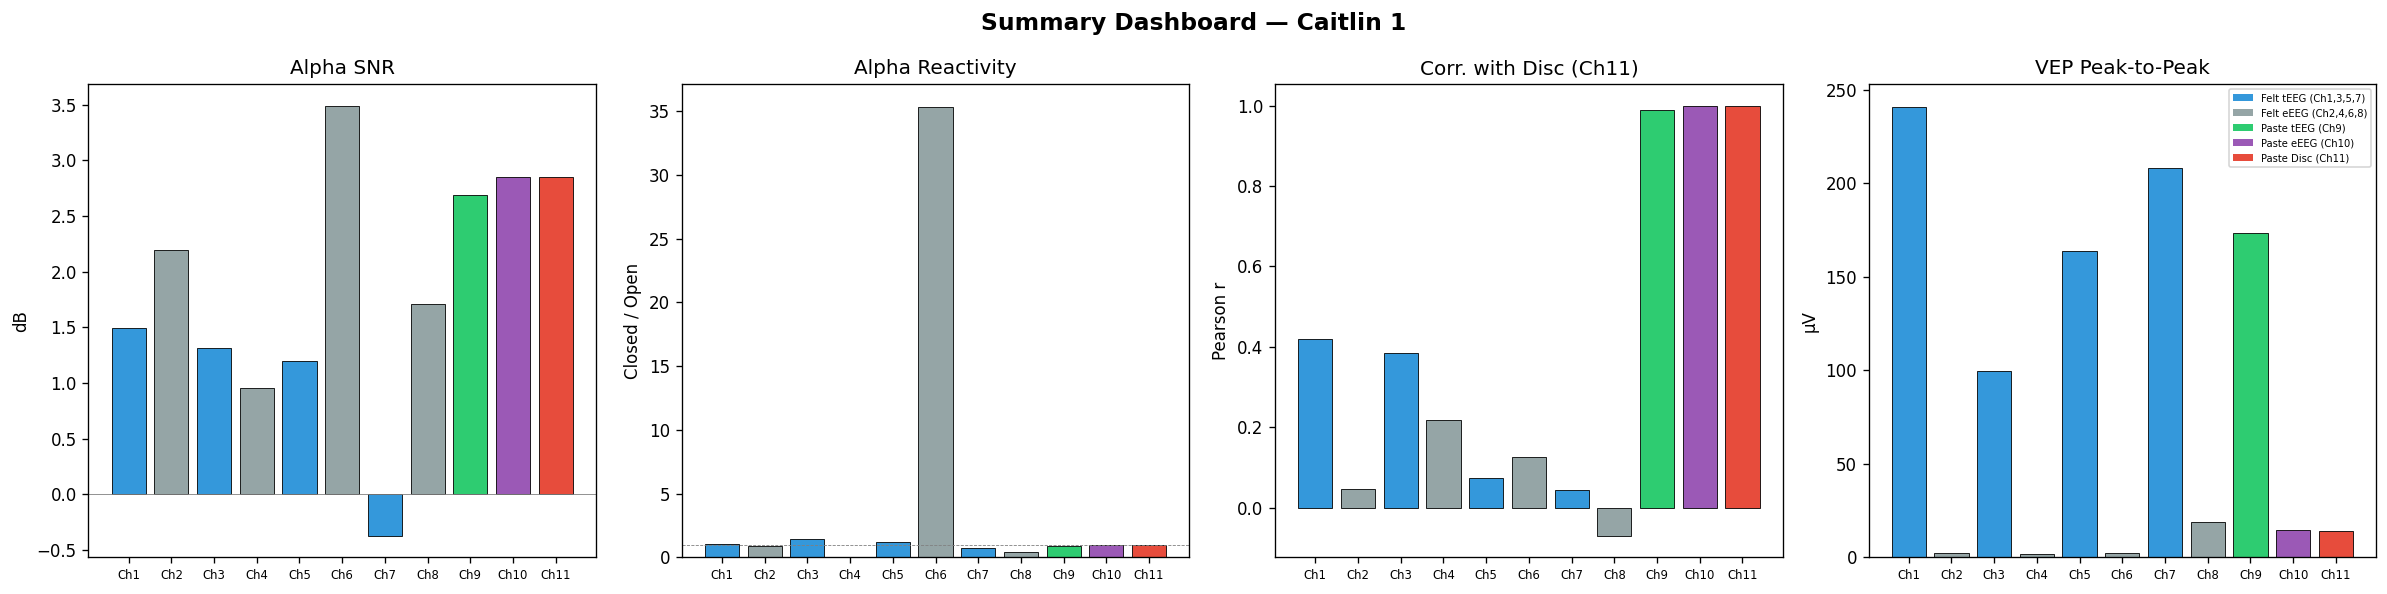

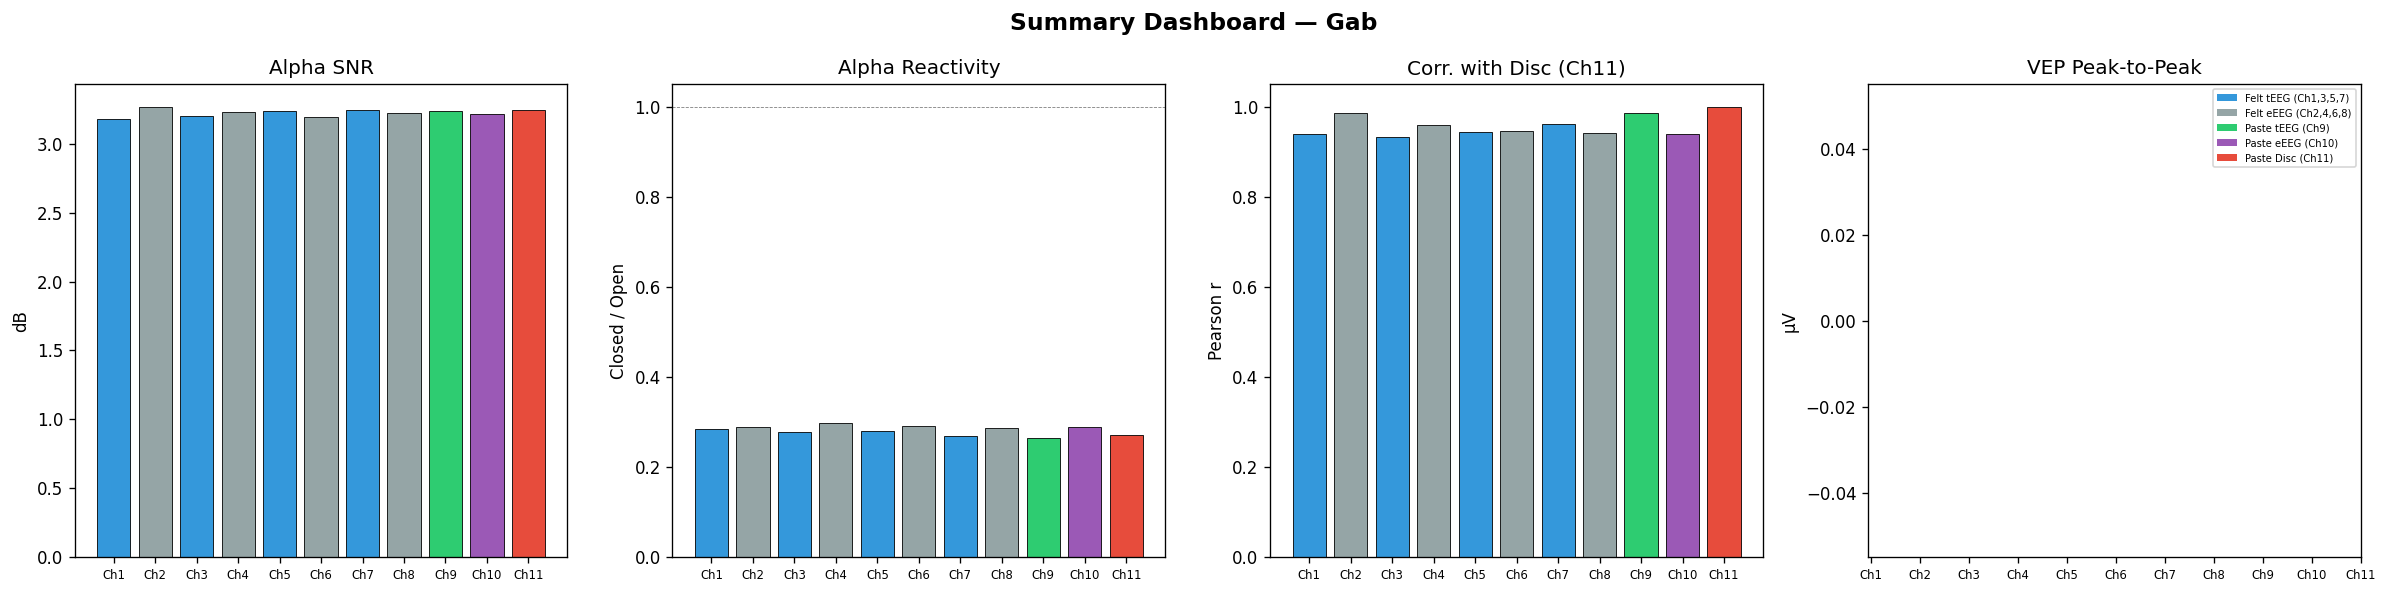

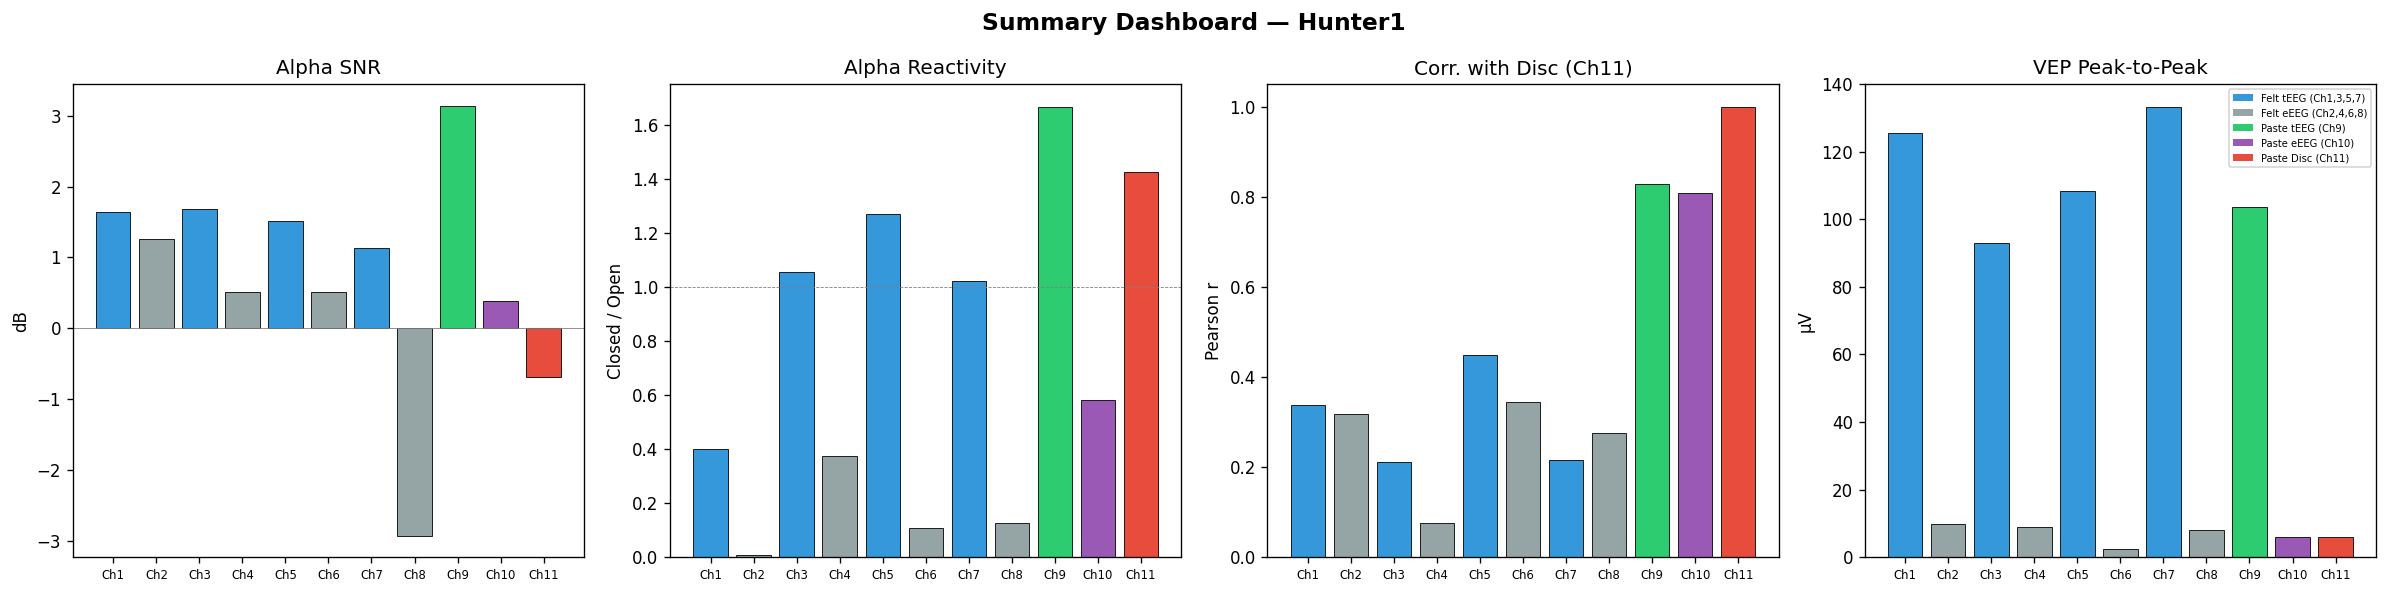

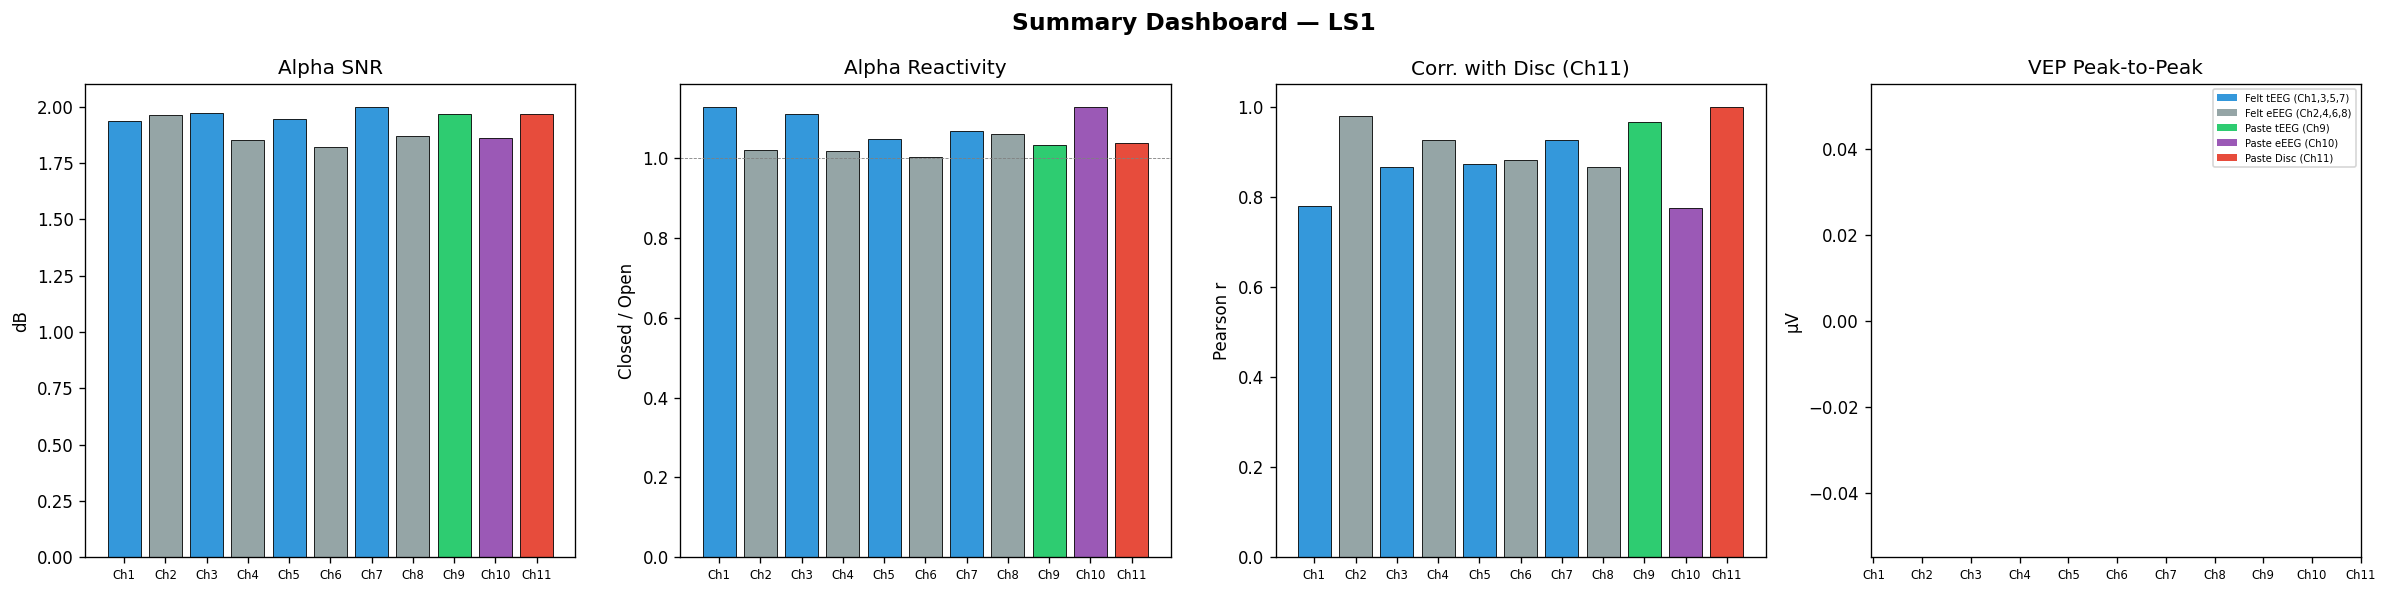

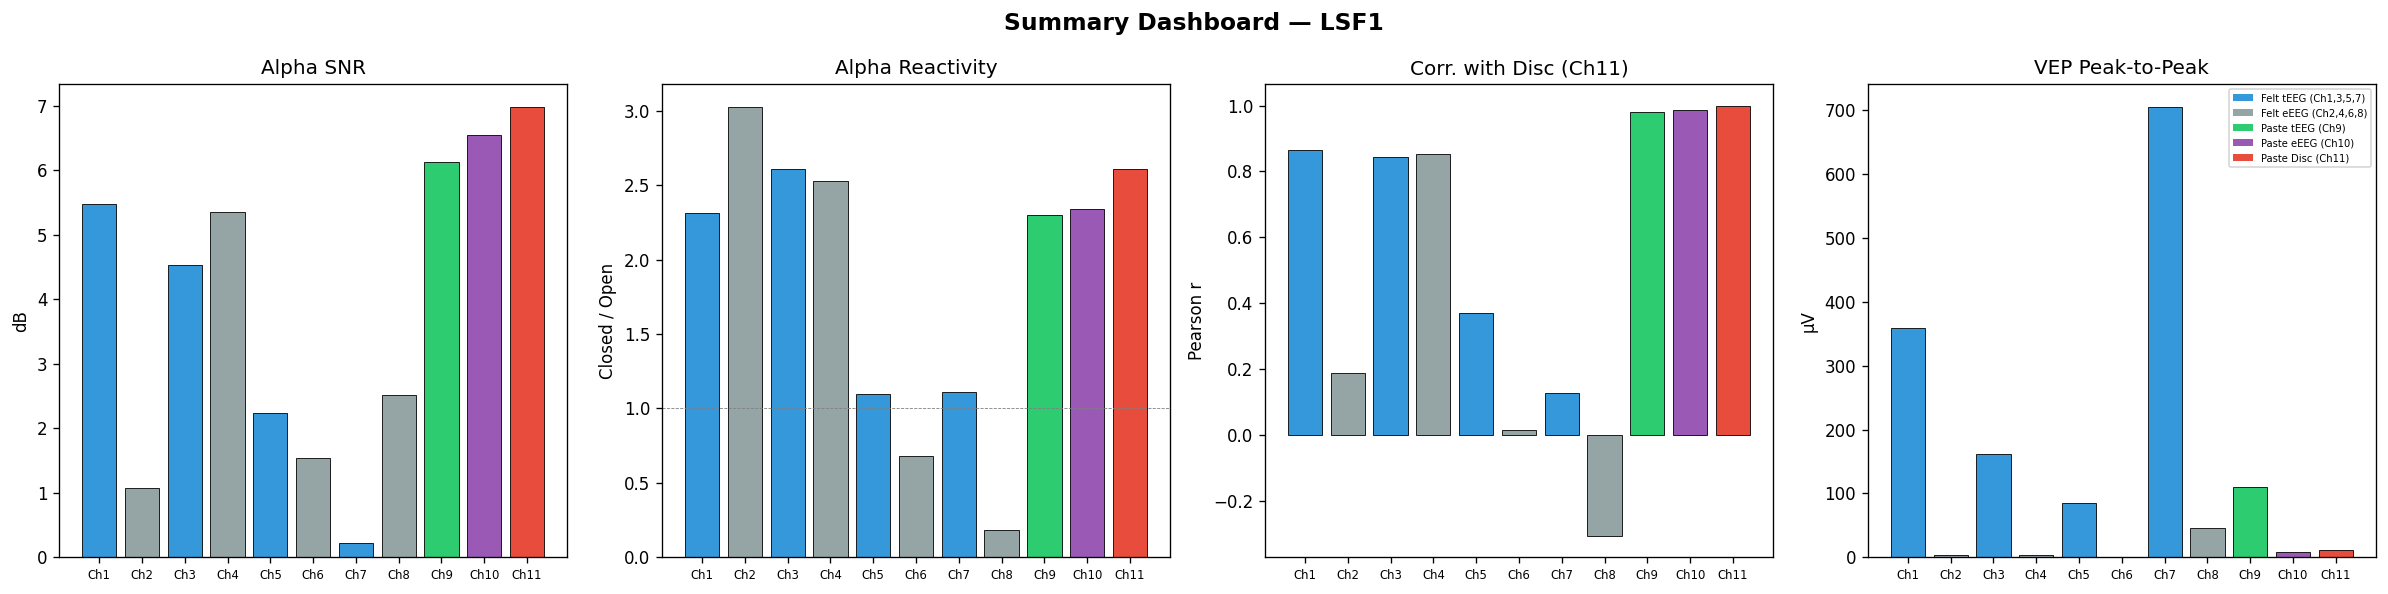

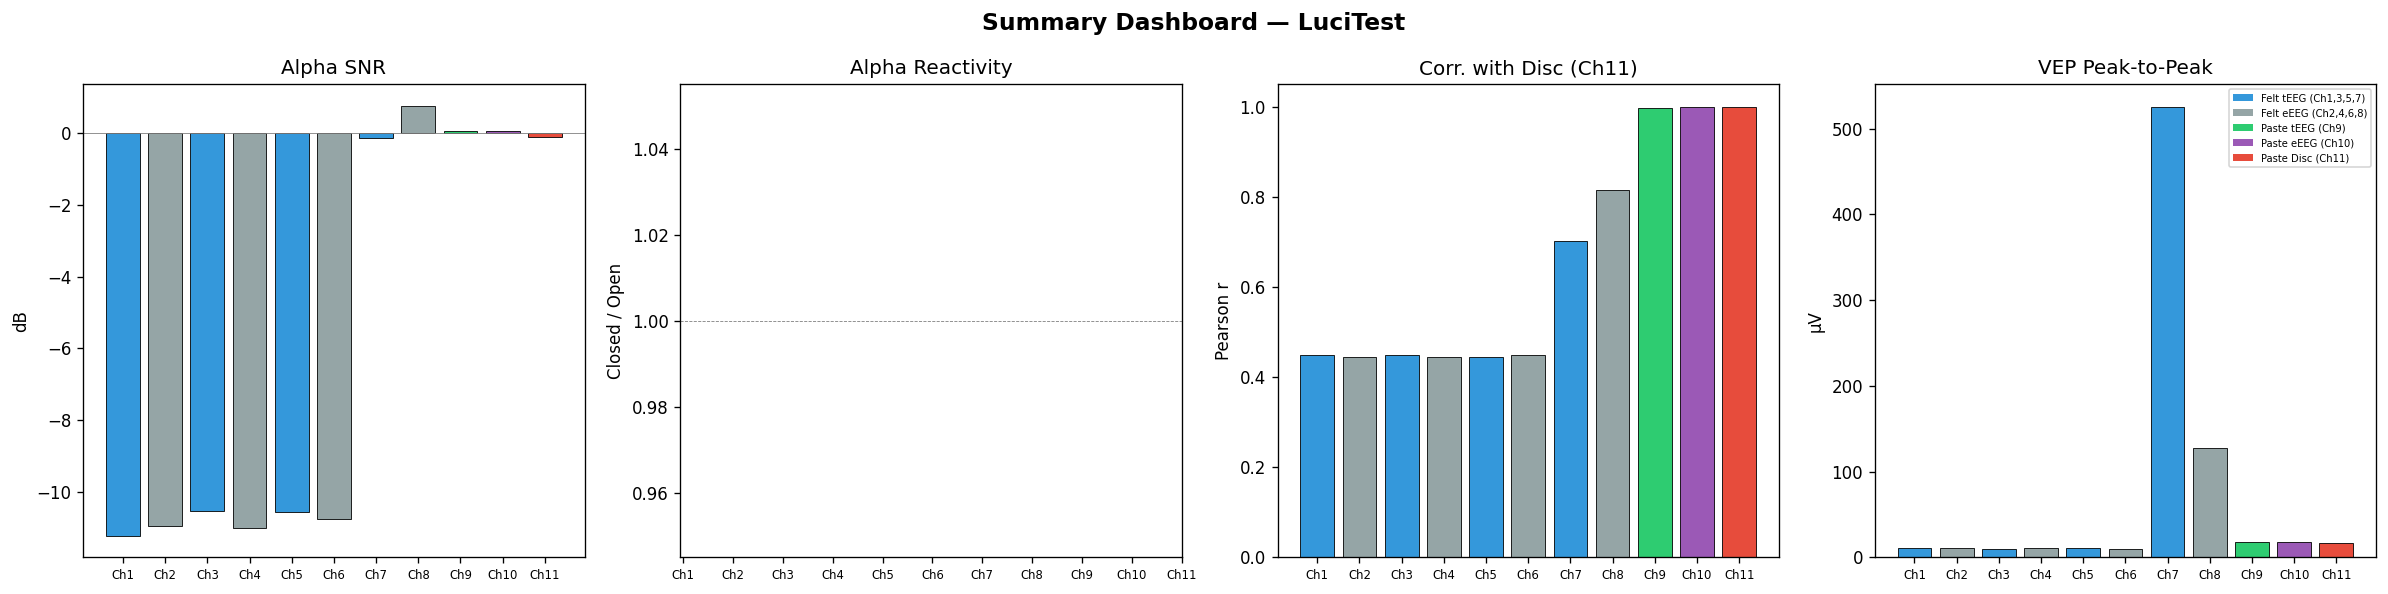

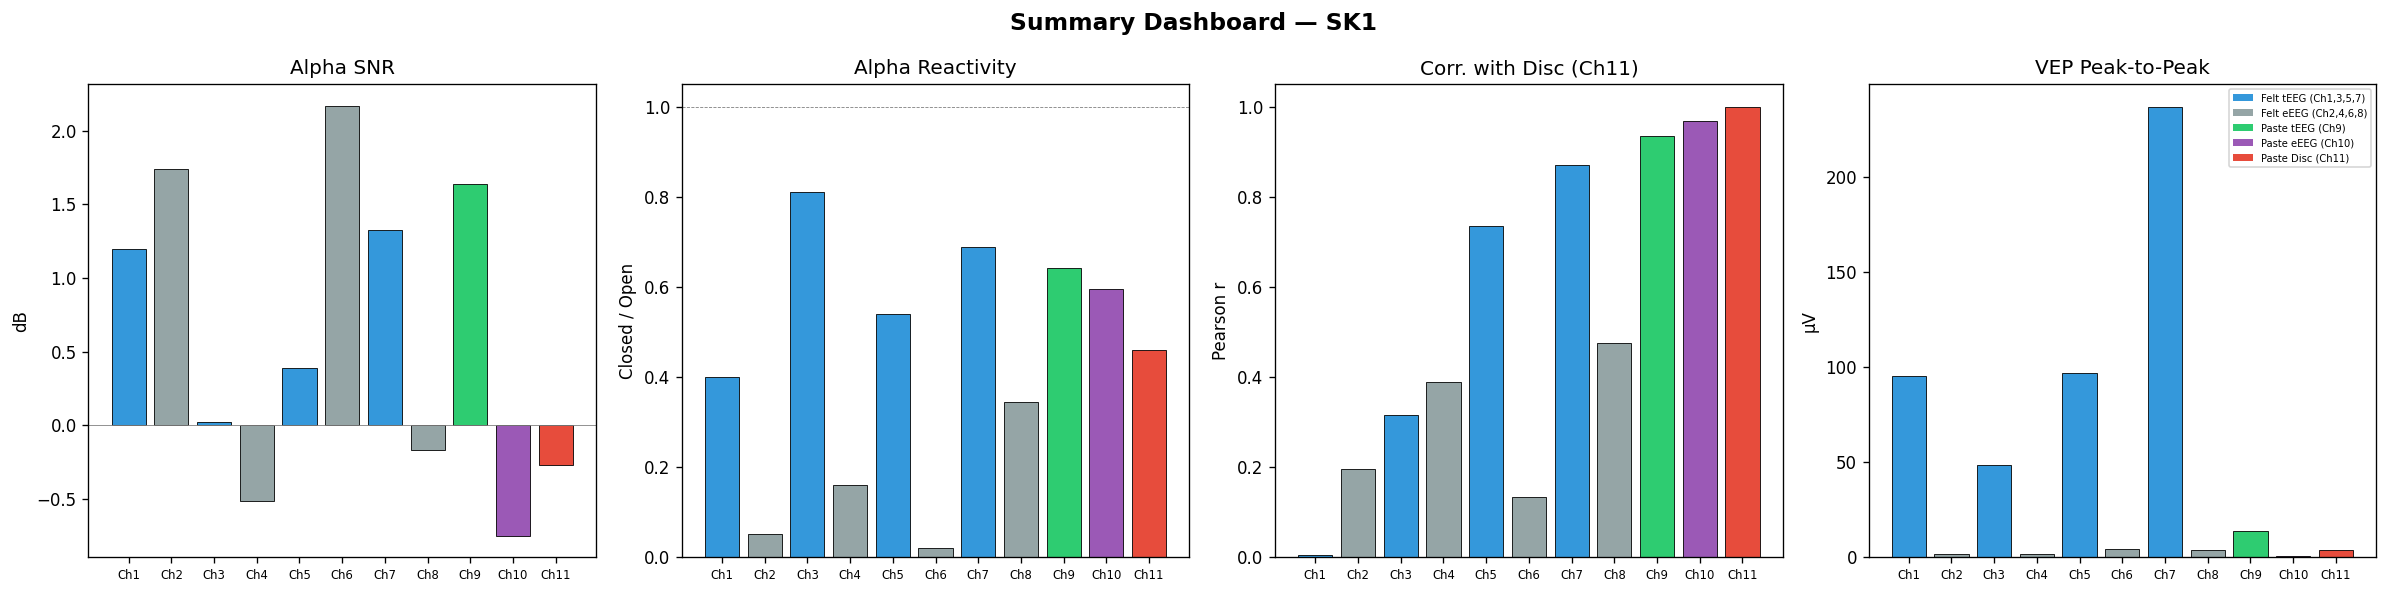

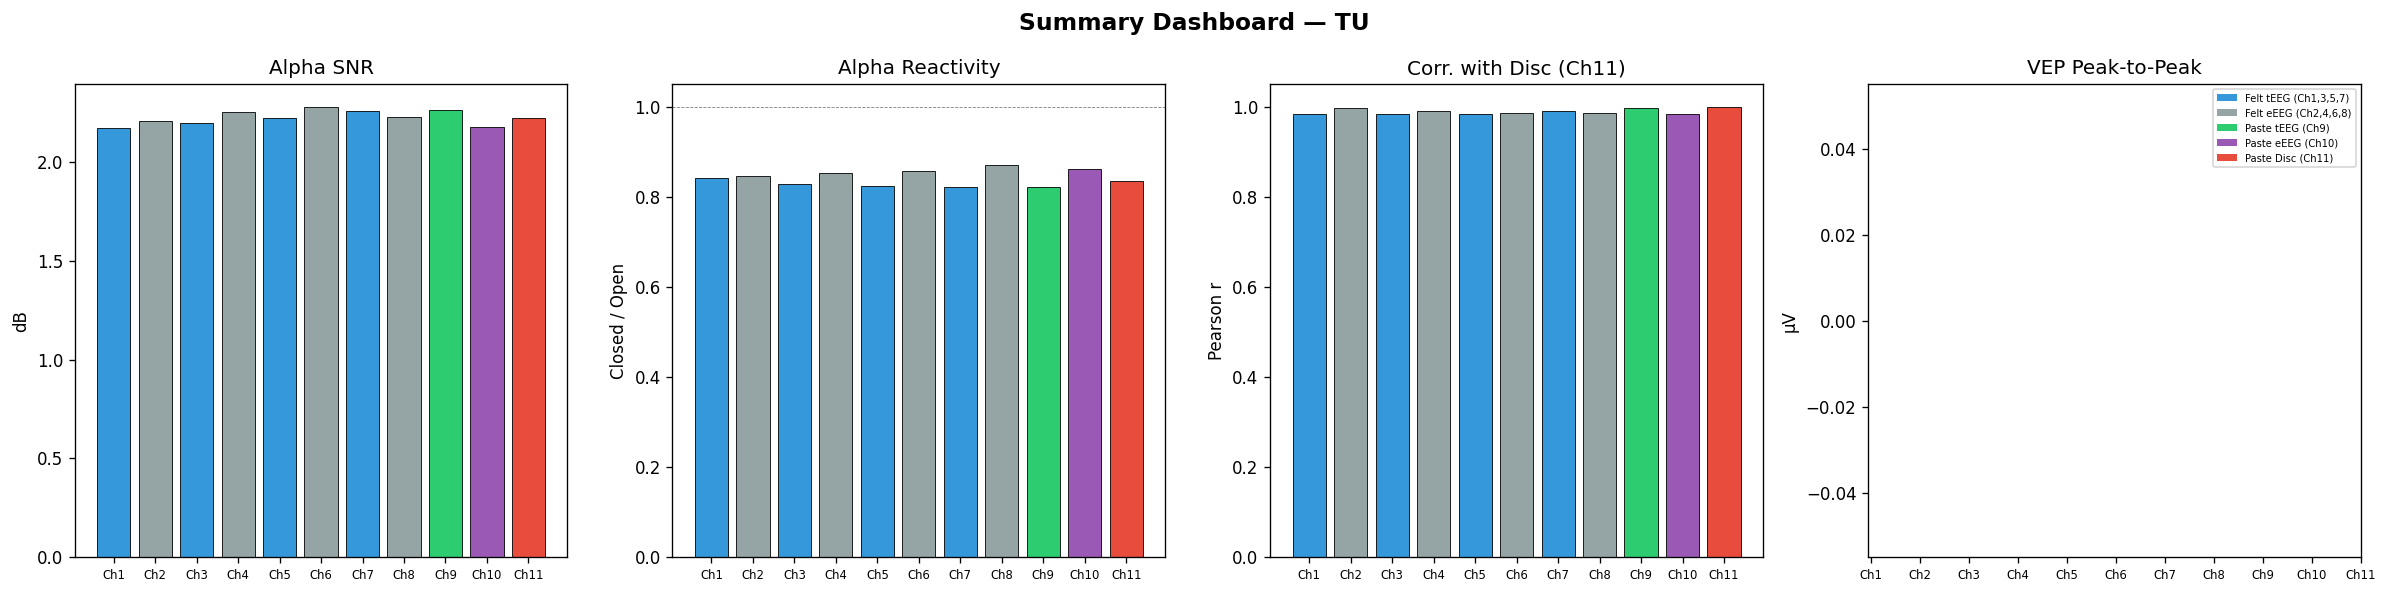

In [4]:
for name in all_results:
    # Save each subject's dashboard figures under output/per_subject_summary/<subject>/
    set_output_section(f"per_subject_summary/{name}")
    plot_subject_summary(all_subjects[name], all_results[name])

## 3. Compile Group Metrics

In [5]:
group = get_group_metrics(all_results)
n_subj = len(group['subject_names'])

print(f"Group metrics compiled for {n_subj} subjects:")
print(f"  Subjects: {group['subject_names']}")
print(f"  Each metric shape: ({n_subj}, {N_CHANNELS})")

# Electrode type groupings
type_names = ['Felt eEEG', 'Felt tEEG', 'Paste eEEG', 'Paste tEEG', 'Disc']
type_indices = [IDX_FELT_EEEG, IDX_FELT_TEEG, IDX_PASTE_EEEG, IDX_PASTE_TEEG, IDX_DISC]
type_colors = ['#95a5a6', '#3498db', '#9b59b6', '#2ecc71', '#e74c3c']

Group metrics compiled for 10 subjects:
  Subjects: ['AH felt TCRE', 'CP1', 'Caitlin 1', 'Gab', 'Hunter1', 'LS1', 'LSF1', 'LuciTest', 'SK1', 'TU']
  Each metric shape: (10, 11)


## 4. Group Comparison — Box Plots

Each box shows the distribution across all subjects for that electrode type. If tEEG boxes overlap with the Disc box, that's evidence they're comparable.

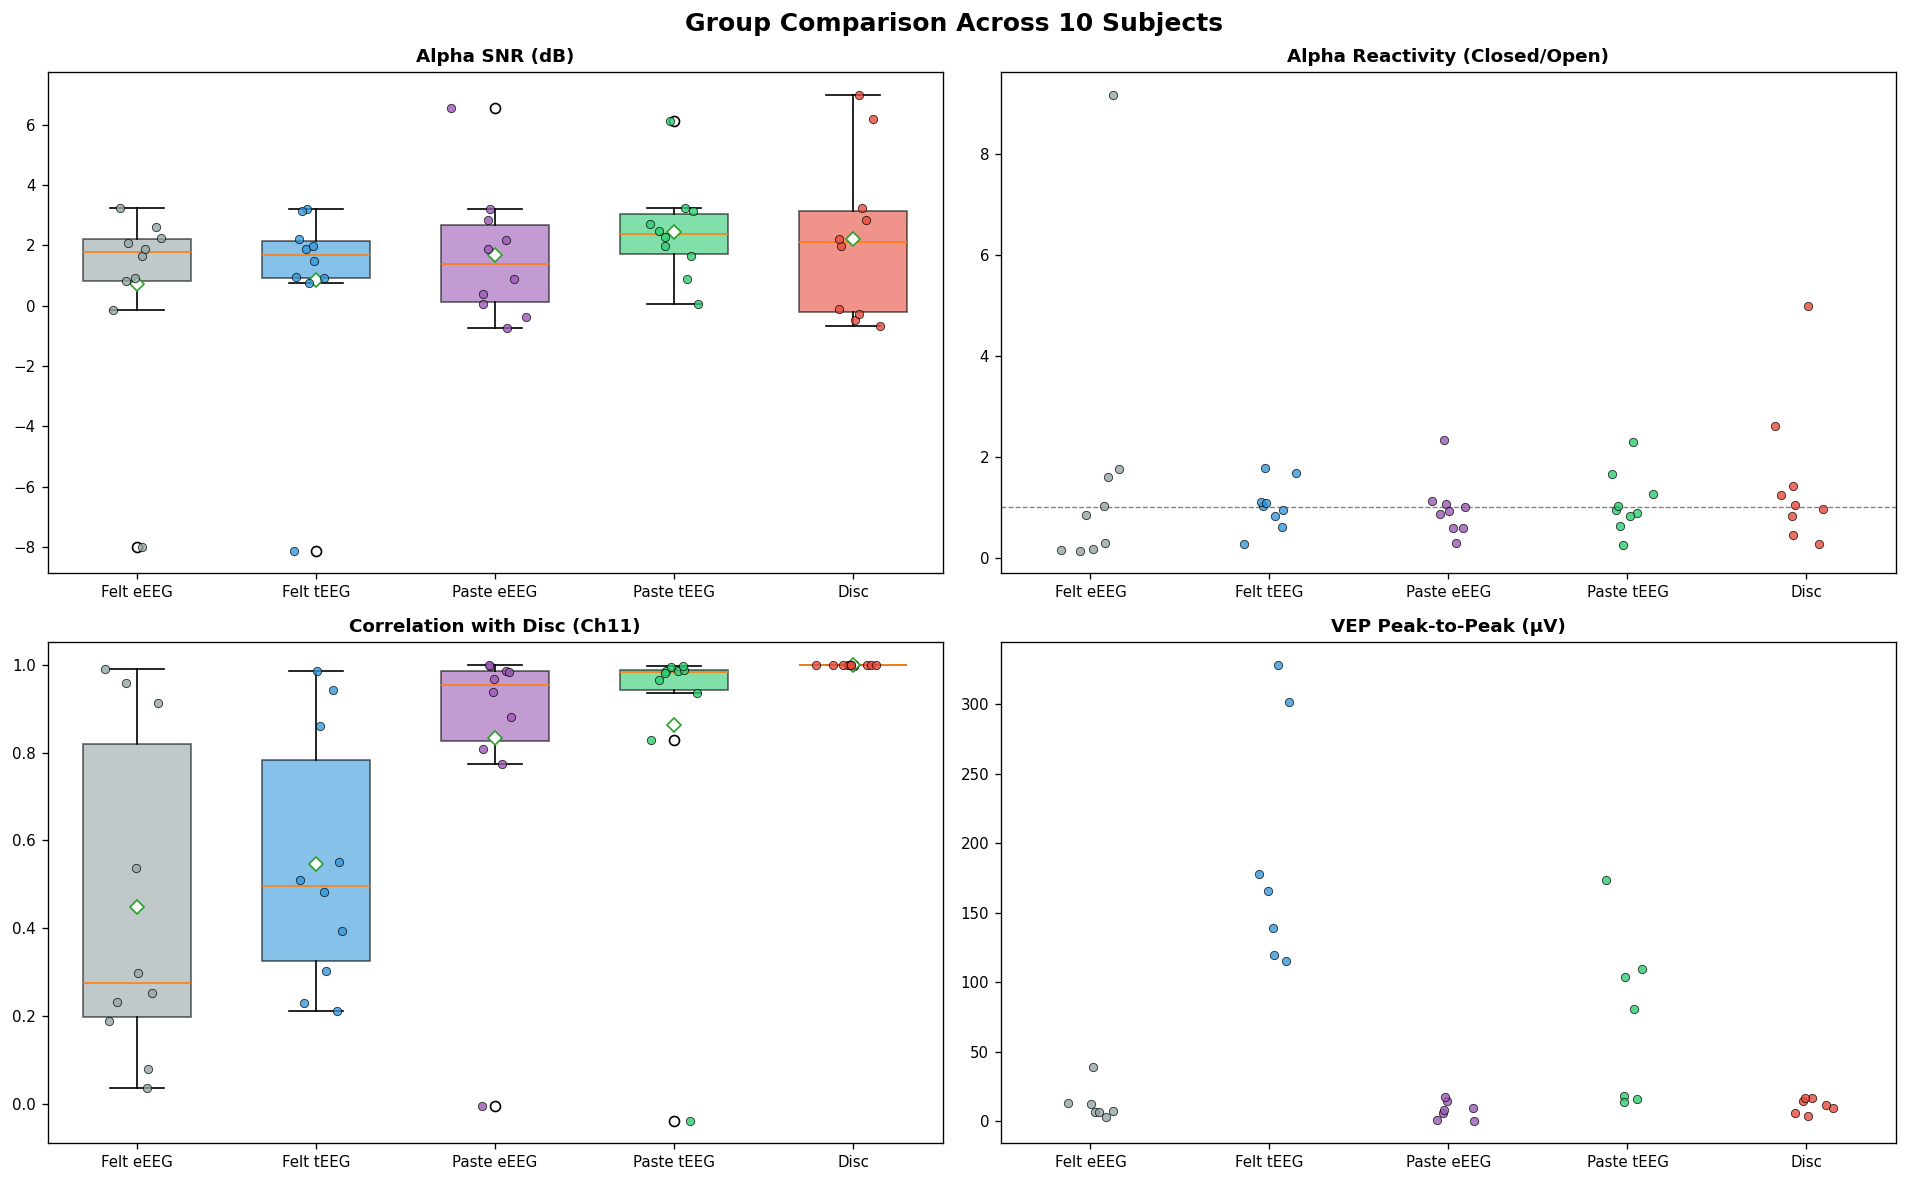

In [6]:
set_output_section('group_comparison_box_plots')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'Group Comparison Across {n_subj} Subjects', fontsize=15, fontweight='bold')

metrics_to_plot = [
    ('alpha_snr', 'Alpha SNR (dB)', None),
    ('alpha_reactivity', 'Alpha Reactivity (Closed/Open)', 1.0),
    ('disc_correlation', 'Correlation with Disc (Ch11)', None),
    ('vep_p2p', 'VEP Peak-to-Peak (µV)', None),
]

for ax, (key, title, hline) in zip(axes.flatten(), metrics_to_plot):
    data_by_type = []
    for idxs in type_indices:
        # Average across channels within each type, then collect per subject
        vals = np.nanmean(group[key][:, idxs], axis=1)  # (n_subj,)
        data_by_type.append(vals)
    
    bp = ax.boxplot(data_by_type, labels=type_names, patch_artist=True,
                     widths=0.6, showmeans=True,
                     meanprops=dict(marker='D', markerfacecolor='white', markersize=6))
    for patch, color in zip(bp['boxes'], type_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    # Overlay individual subject points
    for j, vals in enumerate(data_by_type):
        x_jitter = np.random.normal(j + 1, 0.08, size=len(vals))
        ax.scatter(x_jitter, vals, color=type_colors[j], s=25, alpha=0.8,
                   edgecolors='black', linewidths=0.5, zorder=3)
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(labelsize=9)
    if hline is not None:
        ax.axhline(hline, color='gray', ls='--', lw=0.8)

plt.tight_layout(); plt.show()

## 5. Statistical Tests

**Paired comparisons** (within-subject): For each subject, we average across channels of the same type and compare Felt tEEG vs Disc using a paired t-test (or Wilcoxon signed-rank if n < 20).

In [7]:
print(f"Paired comparisons: Felt tEEG vs Disc (n={n_subj} subjects)")
print(f"Test: {'Paired t-test' if n_subj >= 20 else 'Wilcoxon signed-rank (small n)'}")
print("═" * 90)
print(f"{'Metric':<30} {'Felt tEEG':>10} {'Disc':>10} {'Cohen d':>10} {'p-value':>10} {'Sig?':>6}")
print("─" * 90)

for key, label, _ in metrics_to_plot:
    teeg_vals = np.nanmean(group[key][:, IDX_FELT_TEEG], axis=1)
    disc_vals = np.nanmean(group[key][:, IDX_DISC], axis=1)
    
    # Remove NaN pairs
    valid = ~(np.isnan(teeg_vals) | np.isnan(disc_vals))
    tv, dv = teeg_vals[valid], disc_vals[valid]
    
    if len(tv) >= 3:
        d = cohens_d(tv, dv)
        if len(tv) >= 20:
            stat, p = stats.ttest_rel(tv, dv)
        else:
            stat, p = stats.wilcoxon(tv, dv)
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        d_label = f"{d:>+.2f}" if not np.isnan(d) else "   N/A"
        print(f"{label:<30} {np.mean(tv):>10.3f} {np.mean(dv):>10.3f} {d_label:>10} {p:>10.4f} {sig:>6}")
    else:
        print(f"{label:<30} {'insufficient data':>46}")

print()
print("Also comparing: Paste tEEG vs Disc")
print("─" * 90)

for key, label, _ in metrics_to_plot:
    paste_vals = np.nanmean(group[key][:, IDX_PASTE_TEEG], axis=1)
    disc_vals = np.nanmean(group[key][:, IDX_DISC], axis=1)
    valid = ~(np.isnan(paste_vals) | np.isnan(disc_vals))
    pv, dv = paste_vals[valid], disc_vals[valid]
    
    if len(pv) >= 3:
        d = cohens_d(pv, dv)
        if len(pv) >= 20:
            stat, p = stats.ttest_rel(pv, dv)
        else:
            stat, p = stats.wilcoxon(pv, dv)
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        d_label = f"{d:>+.2f}" if not np.isnan(d) else "   N/A"
        print(f"{label:<30} {np.mean(pv):>10.3f} {np.mean(dv):>10.3f} {d_label:>10} {p:>10.4f} {sig:>6}")
    else:
        print(f"{label:<30} {'insufficient data':>46}")

print()
print("Effect size guide: |d| < 0.2 = negligible, 0.2–0.5 = small, 0.5–0.8 = medium, > 0.8 = large")


Paired comparisons: Felt tEEG vs Disc (n=10 subjects)
Test: Wilcoxon signed-rank (small n)
══════════════════════════════════════════════════════════════════════════════════════════
Metric                          Felt tEEG       Disc    Cohen d    p-value   Sig?
──────────────────────────────────────────────────────────────────────────────────────────
Alpha SNR (dB)                      0.833      2.193      -0.45     0.2754     ns
Alpha Reactivity (Closed/Open)      1.037      1.540      -0.46     0.3008     ns
Correlation with Disc (Ch11)        0.548      1.000      -2.22     0.0020     **
VEP Peak-to-Peak (µV)             192.452     11.128      +2.94     0.0156      *

Also comparing: Paste tEEG vs Disc
──────────────────────────────────────────────────────────────────────────────────────────
Alpha SNR (dB)                      2.449      2.193      +0.11     0.6250     ns
Alpha Reactivity (Closed/Open)      1.093      1.540      -0.40     0.5703     ns
Correlation with Disc (Ch1

## 6. Per-Subject Breakdown Table

In [8]:
for key, label, _ in metrics_to_plot:
    print(f"\n{'─'*80}")
    print(f" {label}")
    print(f"{'─'*80}")
    header = f"{'Subject':<15}"
    for tn in type_names:
        header += f" {tn:>10}"
    print(header)
    
    for s_idx, name in enumerate(group['subject_names']):
        row = f"{name:<15}"
        for idxs in type_indices:
            val = np.nanmean(group[key][s_idx, idxs])
            row += f" {val:>10.3f}"
        print(row)
    
    # Group mean
    row_mean = f"{'MEAN':<15}"
    for idxs in type_indices:
        val = np.nanmean(group[key][:, idxs])
        row_mean += f" {val:>10.3f}"
    print(f"{'─'*15}" + "─" * (11 * len(type_names)))
    print(row_mean)


────────────────────────────────────────────────────────────────────────────────
 Alpha SNR (dB)
────────────────────────────────────────────────────────────────────────────────
Subject          Felt eEEG  Felt tEEG Paste eEEG Paste tEEG       Disc
AH felt TCRE         1.660      1.873      0.873      0.892      6.178
CP1                  0.903      0.934     -0.368      2.479     -0.473
Caitlin 1            2.085      0.908      2.850      2.688      2.849
Gab                  3.228      3.214      3.218      3.234      3.247
Hunter1             -0.158      1.492      0.383      3.142     -0.680
LS1                  1.878      1.965      1.861      1.970      1.968
LSF1                 2.619      3.120      6.548      6.123      6.988
LuciTest            -7.988     -8.120      0.052      0.065     -0.100
SK1                  0.807      0.735     -0.749      1.639     -0.266
TU                   2.240      2.211      2.175      2.260      2.223
────────────────────────────────────────

## 7. Alpha Reactivity by Subject

Bar chart showing each subject's alpha reactivity for tEEG vs Disc. Bars above the dashed line (ratio > 1) indicate successful Berger effect detection.

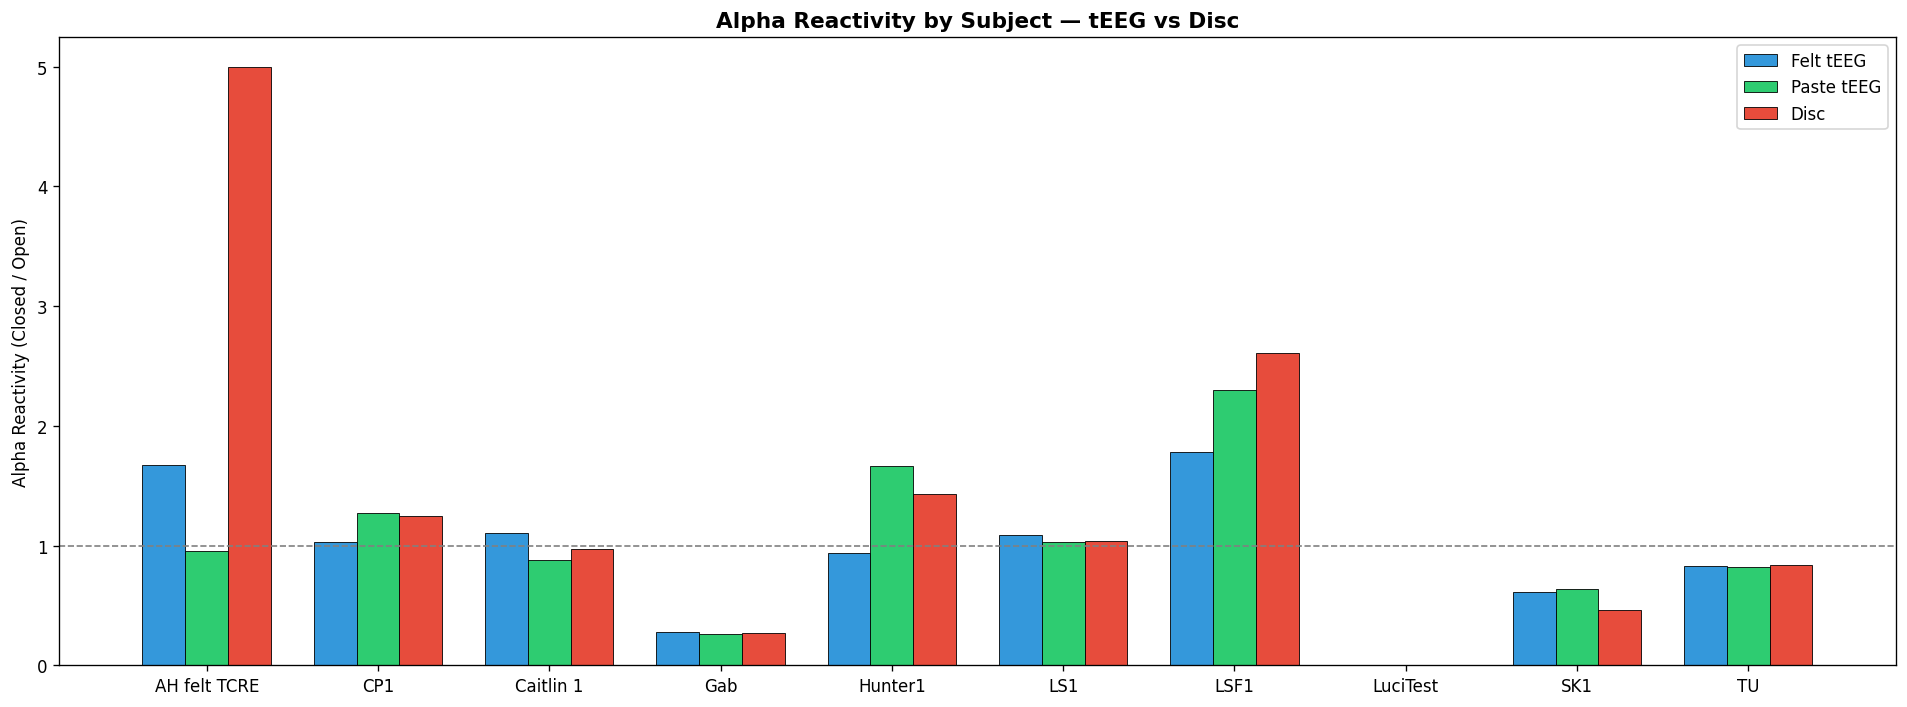

In [9]:
set_output_section('alpha_reactivity_by_subject')

fig, ax = plt.subplots(figsize=(16, 6))

x = np.arange(n_subj)
w = 0.25

teeg_react = np.nanmean(group['alpha_reactivity'][:, IDX_FELT_TEEG], axis=1)
paste_react = np.nanmean(group['alpha_reactivity'][:, IDX_PASTE_TEEG], axis=1)
disc_react = np.nanmean(group['alpha_reactivity'][:, IDX_DISC], axis=1)

ax.bar(x - w, teeg_react, w, color='#3498db', label='Felt tEEG', edgecolor='k', lw=0.5)
ax.bar(x, paste_react, w, color='#2ecc71', label='Paste tEEG', edgecolor='k', lw=0.5)
ax.bar(x + w, disc_react, w, color='#e74c3c', label='Disc', edgecolor='k', lw=0.5)

ax.axhline(1, color='gray', ls='--', lw=1)
ax.set_xticks(x)
ax.set_xticklabels(group['subject_names'], fontsize=10)
ax.set_ylabel('Alpha Reactivity (Closed / Open)')
ax.set_title('Alpha Reactivity by Subject — tEEG vs Disc', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout(); plt.show()

## 7b. Group Eyes Open vs Closed — PSD (Shared Log Scale)

Per-channel PSD averaged across subjects with shared log y-axis for direct cross-channel comparison.
Shows the group-level Berger effect (alpha enhancement during eyes-closed).

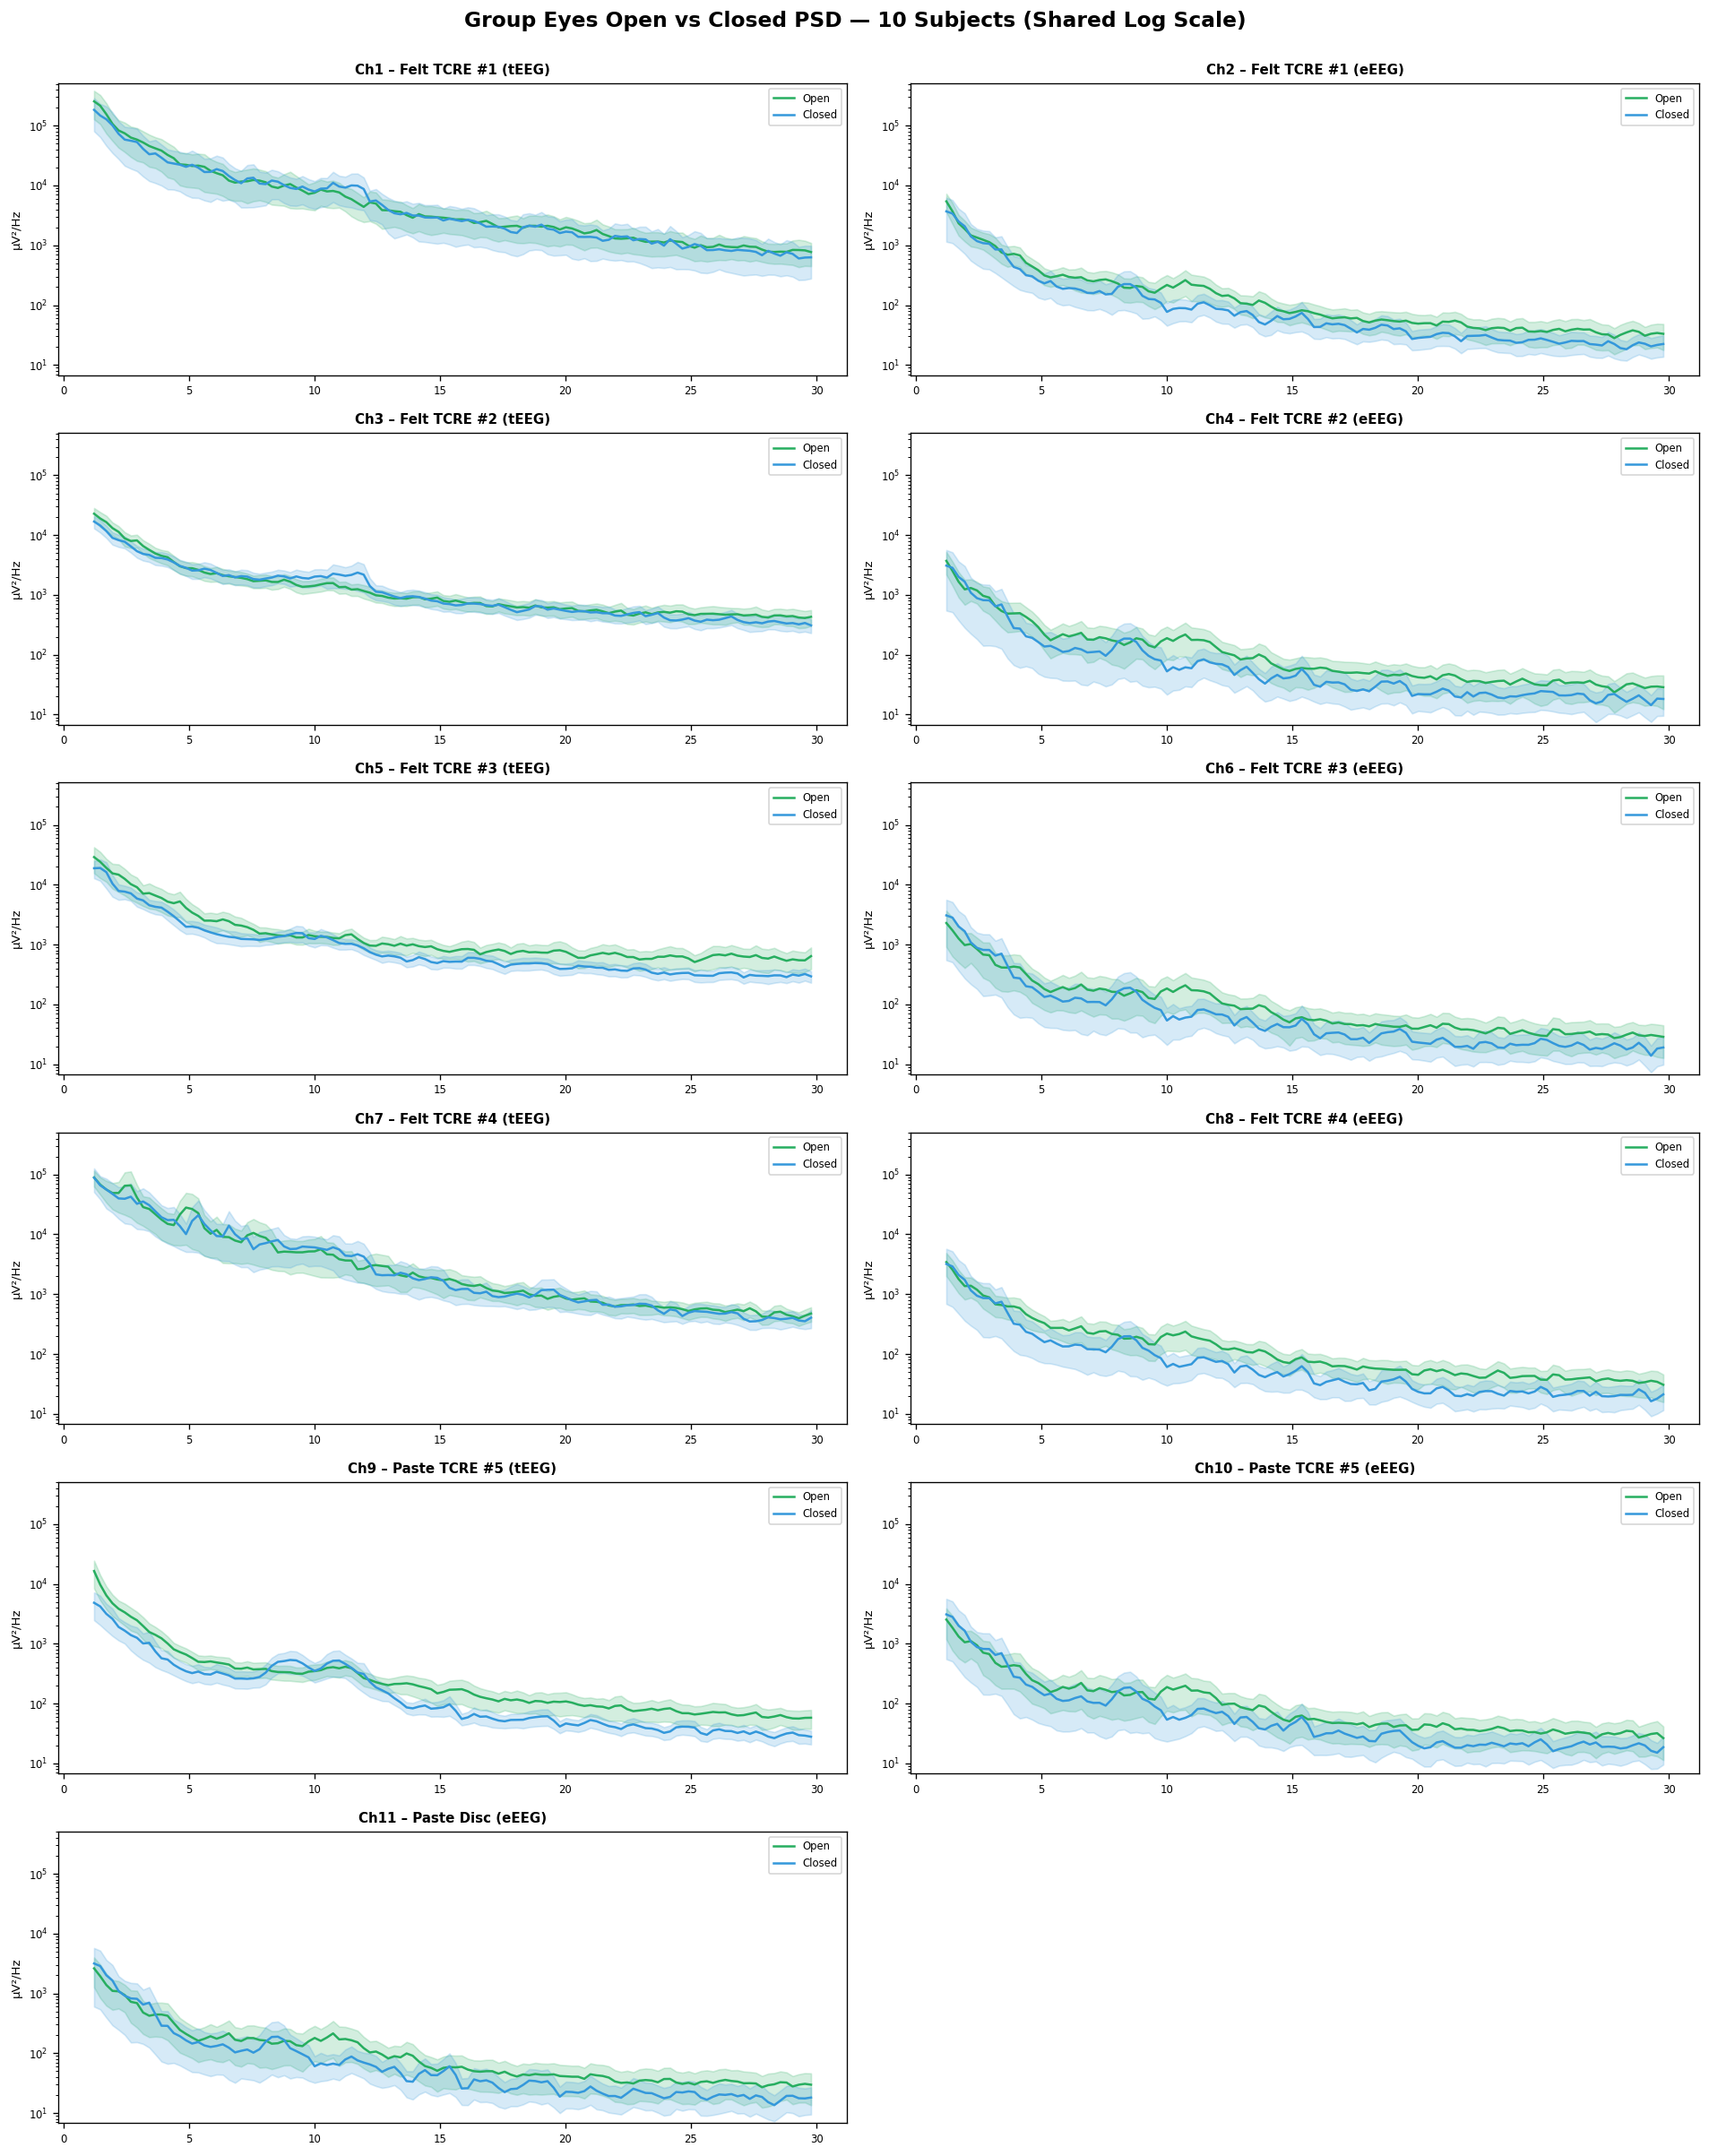

In [10]:
set_output_section('group_psd_open_vs_closed')

# Group eyes open vs closed PSD with shared log scale
fig, axes = plt.subplots(6, 2, figsize=(16, 20))
fig.suptitle(f'Group Eyes Open vs Closed PSD — {n_subj} Subjects (Shared Log Scale)',
             fontsize=14, fontweight='bold', y=1.0)

# Collect PSDs across all subjects
all_pxx_open = [[] for _ in range(N_CHANNELS)]
all_pxx_closed = [[] for _ in range(N_CHANNELS)]
freqs = None

for name in all_subjects:
    subj = all_subjects[name]
    if not subj['open_epochs'] or not subj['close_epochs']:
        continue
    for i in range(N_CHANNELS):
        cleaned = notch_filter(subj['eeg'][i])
        od = np.concatenate([cleaned[ep['start']:ep['end']] for ep in subj['open_epochs']])
        cd = np.concatenate([cleaned[ep['start']:ep['end']] for ep in subj['close_epochs']])
        f_o, pxx_o = signal.welch(od, fs=FS, nperseg=4096)
        f_c, pxx_c = signal.welch(cd, fs=FS, nperseg=4096)
        if freqs is None:
            freqs = f_o
        all_pxx_open[i].append(pxx_o)
        all_pxx_closed[i].append(pxx_c)

mask = (freqs >= 1) & (freqs <= 30)

# First pass: find global min/max across all channels for shared scale
global_max = 0
global_min = np.inf
mean_psds = []
for i in range(N_CHANNELS):
    mean_o = np.mean(all_pxx_open[i], axis=0)
    mean_c = np.mean(all_pxx_closed[i], axis=0)
    sem_o = np.std(all_pxx_open[i], axis=0) / np.sqrt(len(all_pxx_open[i]))
    sem_c = np.std(all_pxx_closed[i], axis=0) / np.sqrt(len(all_pxx_closed[i]))
    mean_psds.append((mean_o, mean_c, sem_o, sem_c))
    vals = np.concatenate([mean_o[mask], mean_c[mask]])
    global_max = max(global_max, vals.max())
    global_min = min(global_min, vals[vals > 0].min())

# Second pass: plot with shared log y-scale
for i in range(N_CHANNELS):
    ax = axes.flatten()[i]
    mean_o, mean_c, sem_o, sem_c = mean_psds[i]
    ax.semilogy(freqs[mask], mean_o[mask], lw=1.5, color='#27ae60', label='Open')
    ax.semilogy(freqs[mask], mean_c[mask], lw=1.5, color='#3498db', label='Closed')
    ax.fill_between(freqs[mask],
                    np.maximum(mean_o[mask] - sem_o[mask], 1e-10),
                    mean_o[mask] + sem_o[mask], alpha=0.2, color='#27ae60')
    ax.fill_between(freqs[mask],
                    np.maximum(mean_c[mask] - sem_c[mask], 1e-10),
                    mean_c[mask] + sem_c[mask], alpha=0.2, color='#3498db')
    ax.set_ylim(global_min * 0.5, global_max * 2)
    ax.set_title(CH_LABELS[i], fontsize=9, fontweight='bold')
    ax.set_ylabel('µV²/Hz', fontsize=8)
    ax.legend(fontsize=7); ax.tick_params(labelsize=7)
axes.flatten()[11].set_visible(False)
plt.tight_layout(); plt.show()


## 8. Correlation Scatter: tEEG vs Disc

If tEEG tracks the disc well, points should cluster near the diagonal.

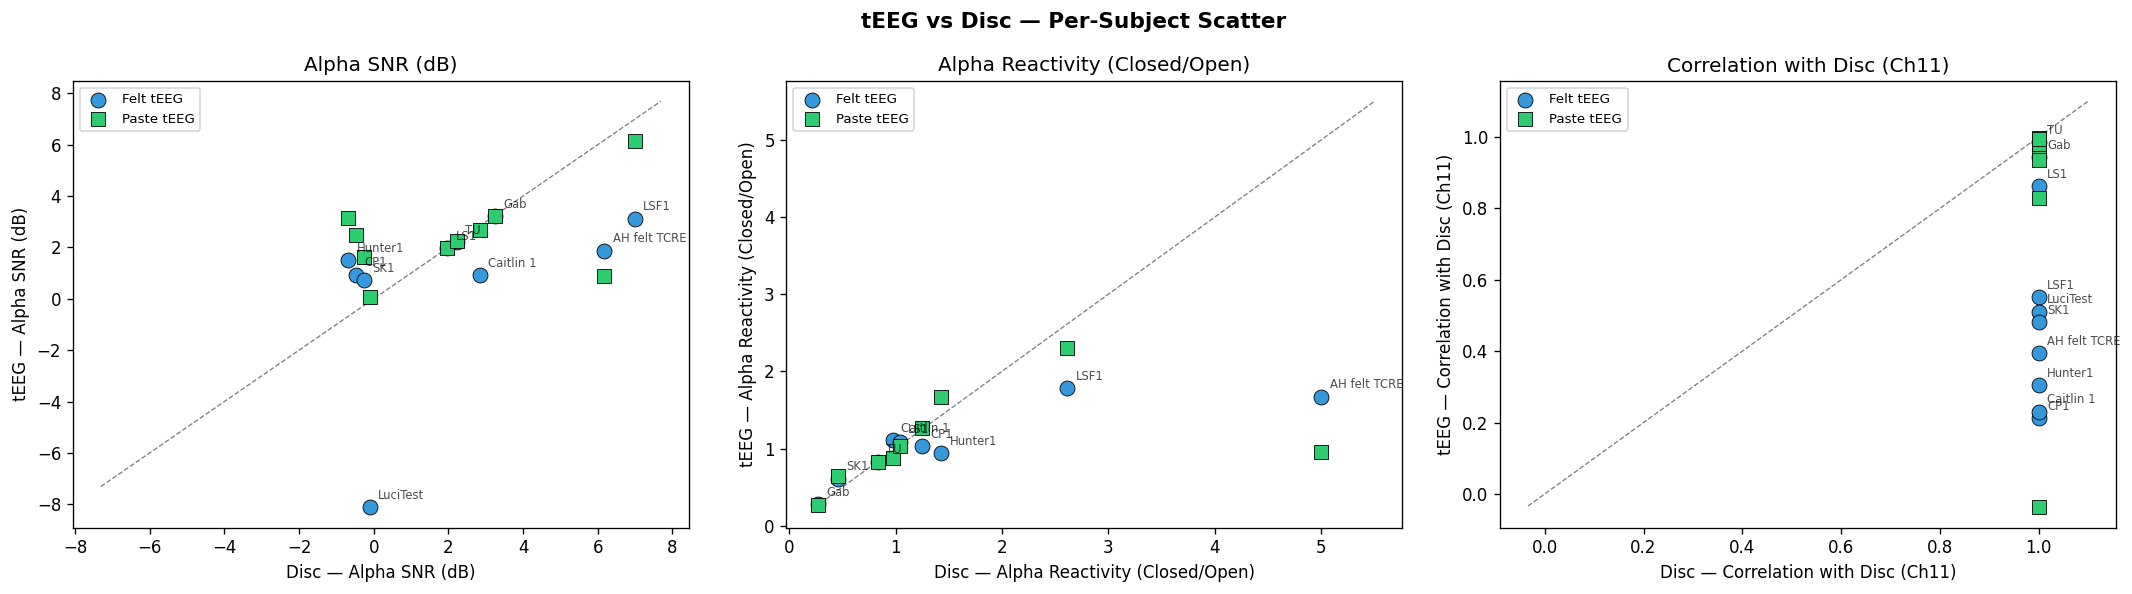

In [11]:
set_output_section('correlation_scatter_teeg_vs_disc')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('tEEG vs Disc — Per-Subject Scatter', fontsize=13, fontweight='bold')

for ax, (key, label, _) in zip(axes, metrics_to_plot[:3]):
    teeg_vals = np.nanmean(group[key][:, IDX_FELT_TEEG], axis=1)
    disc_vals = np.nanmean(group[key][:, IDX_DISC], axis=1)
    
    ax.scatter(disc_vals, teeg_vals, s=80, color='#3498db', edgecolors='black',
               linewidths=0.5, zorder=3, label='Felt tEEG')
    
    paste_vals = np.nanmean(group[key][:, IDX_PASTE_TEEG], axis=1)
    ax.scatter(disc_vals, paste_vals, s=80, color='#2ecc71', edgecolors='black',
               linewidths=0.5, zorder=3, marker='s', label='Paste tEEG')
    
    # Add diagonal
    all_vals = np.concatenate([disc_vals, teeg_vals, paste_vals])
    lim = [np.nanmin(all_vals) * 0.9, np.nanmax(all_vals) * 1.1]
    ax.plot(lim, lim, 'k--', lw=0.8, alpha=0.5)
    
    # Add subject labels
    for j, name in enumerate(group['subject_names']):
        ax.annotate(name, (disc_vals[j], teeg_vals[j]), fontsize=7, alpha=0.7,
                     xytext=(5, 5), textcoords='offset points')
    
    ax.set_xlabel(f'Disc — {label}')
    ax.set_ylabel(f'tEEG — {label}')
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

## 9. Save All Per-Subject Figures (Optional)

Uncomment and run to save detailed per-subject figures to `figures/<subject_name>/`.

In [ ]:
# Uncomment to generate and save all figures:

# import os
# for name in all_results:
#     save_dir = os.path.join('figures', name)
#     print(f"Generating figures for {name}...")
#     plot_subject_full(all_subjects[name], all_results[name],
#                       save_dir=save_dir, show=False)
#     print(f"  → Saved to {save_dir}/")
# print("Done!")

## 9b. Spectrogram SSIM: tEEG vs eEEG

Structural Similarity Index (SSIM) measures how similar the time-frequency structure is between paired tEEG and eEEG spectrograms from the **same TCRE**. An SSIM close to 1.0 means the tEEG Laplacian output captures the same spectral dynamics as the conventional derivation.


In [13]:
set_output_section('spectrogram_ssim')

# Group SSIM analysis
if not HAS_SSIM:
    print('SSIM is unavailable because scikit-image is not installed.')
    print('Install it and re-run this notebook: pip install scikit-image')
elif 'ssim_values' not in group:
    print('No SSIM data found in group metrics.')
else:
    ssim_data = group['ssim_values']  # shape: (n_subjects, 5)
    pair_labels = group['ssim_pair_labels']

    if np.all(np.isnan(ssim_data)):
        print('SSIM values are all NaN (no valid SSIM computed for any subject/pair).')
        print('Most common cause: scikit-image missing at analysis time; re-run after installing it.')
    else:
        print('Spectrogram SSIM per TCRE pair (mean ± std across subjects)')
        print('═' * 70)
        print(f"{'TCRE Pair':<25} {'N':>4} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
        print('─' * 70)
        for j, lbl in enumerate(pair_labels):
            vals = ssim_data[:, j]
            valid = vals[~np.isnan(vals)]
            if len(valid) > 0:
                print(f'{lbl:<25} {len(valid):>4d} {np.mean(valid):>10.3f} {np.std(valid):>10.3f} '
                      f'{np.min(valid):>10.3f} {np.max(valid):>10.3f}')
            else:
                print(f'{lbl:<25} {0:>4d} {"---":>10} {"---":>10} {"---":>10} {"---":>10}')
        print()

        # Group bar chart (only plot pairs with at least one valid subject)
        valid_counts = np.sum(~np.isnan(ssim_data), axis=0)
        means = np.nanmean(ssim_data, axis=0)
        stds = np.nanstd(ssim_data, axis=0)

        pair_mask = valid_counts > 0
        means_p = means[pair_mask]
        stds_p = stds[pair_mask]
        labels_p = [lbl for lbl, ok in zip(pair_labels, pair_mask) if ok]

        fig, ax = plt.subplots(figsize=(10, 5))
        colors_ssim = ['#3498db'] * 4 + ['#2ecc71']
        colors_p = [c for c, ok in zip(colors_ssim, pair_mask) if ok]

        ax.bar(range(len(means_p)), means_p, yerr=stds_p, capsize=5,
               color=colors_p, edgecolor='k', lw=0.5)
        ax.set_xticks(range(len(means_p)))
        ax.set_xticklabels(labels_p, fontsize=10)
        ax.set_ylabel('SSIM', fontsize=11)
        ax.set_title(f'Group Spectrogram SSIM: tEEG vs eEEG (n={n_subj})',
                     fontsize=13, fontweight='bold')
        ax.set_ylim(0, 1)
        ax.axhline(0.8, color='gray', lw=0.8, ls='--', alpha=0.5)
        for j, (m, s) in enumerate(zip(means_p, stds_p)):
            ax.text(j, m + s + 0.03, f'{m:.3f}', ha='center', fontsize=10, fontweight='bold')
        plt.tight_layout(); plt.show()

        # Per-subject heatmap (mask NaNs so they're visibly "missing")
        fig, ax = plt.subplots(figsize=(8, max(3, n_subj * 0.5 + 1)))
        ssim_ma = np.ma.array(ssim_data, mask=np.isnan(ssim_data))
        cmap = plt.cm.RdYlGn.copy()
        cmap.set_bad(color='#f0f0f0')

        im = ax.imshow(ssim_ma, cmap=cmap, vmin=0, vmax=1, aspect='auto')
        ax.set_xticks(range(len(pair_labels)))
        ax.set_xticklabels(pair_labels, fontsize=9)
        ax.set_yticks(range(n_subj))
        ax.set_yticklabels(group['subject_names'], fontsize=9)
        ax.set_title('SSIM per Subject × TCRE Pair', fontsize=12, fontweight='bold')
        for si in range(n_subj):
            for pj in range(len(pair_labels)):
                v = ssim_data[si, pj]
                if not np.isnan(v):
                    ax.text(pj, si, f'{v:.2f}', ha='center', va='center', fontsize=8,
                            color='white' if v < 0.5 else 'black')
        plt.colorbar(im, ax=ax, label='SSIM', shrink=0.8)
        plt.tight_layout(); plt.show()


SSIM is unavailable because scikit-image is not installed.
Install it and re-run this notebook: pip install scikit-image


## 11. Conclusions

### Key Questions to Answer from This Data:

1. **Do tEEG electrodes detect the Berger effect?**  
   → Check if alpha reactivity > 1 for tEEG channels (Section 7)

2. **Are tEEG alpha metrics comparable to disc?**  
   → Check box plots (Section 4) and p-values (Section 5)

3. **Does electrolyte matter?**  
   → Compare saltwater tEEG vs paste tEEG

4. **Do tEEG electrodes capture VEPs?**  
   → Compare VEP peak-to-peak amplitudes

### Statistical Interpretation
- **p < 0.05:** Significant difference between tEEG and disc (they're NOT equivalent)
- **p > 0.05:** No significant difference (evidence FOR equivalence — good for your hypothesis!)
- With n=9, consider these preliminary results. A larger sample would give more power.

### Caveats
- Channel mapping (odd=Conv, even=tEEG) is inferred — verify with hardware docs
- Electrode scalp positions not controlled/documented across subjects
- No artifact rejection applied (ICA recommended for publication-quality results)
